# Import Required Libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Loading the Dataset

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')
print(f"Dataset uploaded to DataFrame df, having shape {df.shape}")

Dataset uploaded to DataFrame df, having shape (400, 3)


# Exploring the Dataset

## Dimension and Size

In [3]:
print(f"No. of Rows : {df.shape[0]}\nNo. of Columns : {df.shape[1]}\nTotal No. of Cells : {df.size}")

No. of Rows : 400
No. of Columns : 3
Total No. of Cells : 1200


## Displaying Sample Rows

In [4]:
print("Top 5 rows")
display(df.head())

Top 5 rows


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
print("Last 5 rows")
display(df.tail())

Last 5 rows


,Age,EstimatedSalary,Purchased
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0
399,49,36000,1


In [6]:
print("Randomly selected 5 rows")
display(df.sample(5))

Randomly selected 5 rows


,Age,EstimatedSalary,Purchased
328,36,118000,1
192,29,43000,0
208,40,142000,1
364,42,104000,1
249,35,97000,1


## Metadata

In [7]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


None

## Statistical Summary

In [8]:
display(df.describe())

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


# Data Preprocessing

## Converting to Suitable Data Types

In [13]:
print("Before Type Conversion")
display(df.dtypes)

Before Type Conversion


Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object

In [10]:
df.nunique()

Age                 43
EstimatedSalary    117
Purchased            2
dtype: int64

In [12]:
df['Purchased'].unique()

array([0, 1])

In [14]:
df['Purchased'] = df['Purchased'].astype('category')

In [15]:
print("After Type Conversion")
display(df.dtypes)

After Type Conversion


Age                   int64
EstimatedSalary       int64
Purchased          category
dtype: object

## Identifying NULL Values

In [16]:
df.isnull()

,Age,EstimatedSalary,Purchased
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
395,False,False,False
396,False,False,False
397,False,False,False
398,False,False,False


In [17]:
print(f"No. of NULL Values per Column\n{df.isnull().sum()}\n-----------------------------------------\nTotal No. of NULL Values : {df.isnull().sum().sum()}")

No. of NULL Values per Column
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
-----------------------------------------
Total No. of NULL Values : 0


## Feature Scaling

In [20]:
scaler = MinMaxScaler()
df[['Age', 'EstimatedSalary']] = scaler.fit_transform(df[['Age','EstimatedSalary']])

In [21]:
df.head()

,Age,EstimatedSalary,Purchased
0,0.023810,0.029630,0
1,0.404762,0.037037,0
2,0.190476,0.207407,0
3,0.214286,0.311111,0
4,0.023810,0.451852,0


## Detecting Outliers

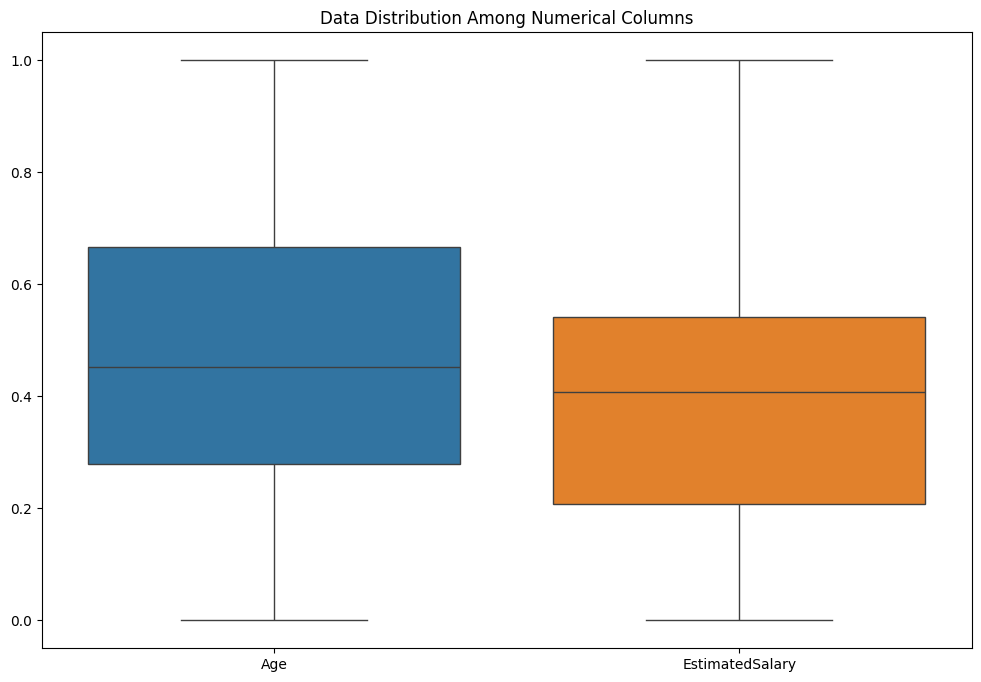

In [22]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df.drop('Purchased',axis=1))
plt.title("Data Distribution Among Numerical Columns")
plt.show()

# Quick EDA

## Paired Plots

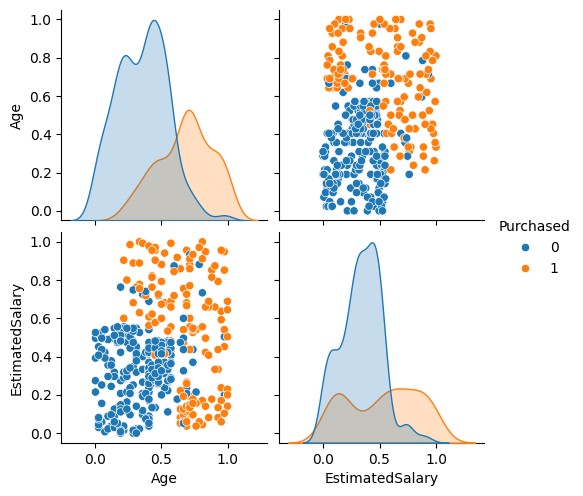

In [23]:
sns.pairplot(df, hue='Purchased')
plt.show()

## Correlation Matrix

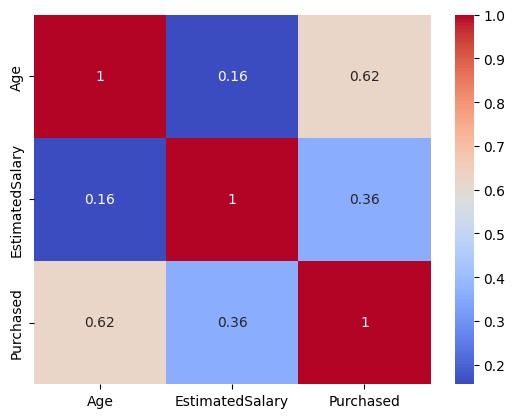

In [24]:
sns.heatmap(data=df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Model Training

## Target Assignment

In [28]:
x = df.drop('Purchased',axis=1)
y = df['Purchased']
print(f"Independent Features : {x.columns}\nDependent Feature : {y.name}")

Independent Features : Index(['Age', 'EstimatedSalary'], dtype='object')
Dependent Feature : Purchased


## Splitting Data into Training and Testing Datasets

In [30]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

## Training Model

In [31]:
model = LogisticRegression()

In [32]:
model.fit(X_train, y_train)

LogisticRegression()

# Model Evaluation

In [36]:
y_pred = model.predict(X_test)

In [41]:
display(y_pred[:5])

array([0, 1, 0, 1, 0])

In [39]:
display(y_test.head())

209    0
280    1
33     0
210    1
93     0
Name: Purchased, dtype: category
Categories (2, int64): [0, 1]

## Confusion Matrix

In [44]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel() #2D -> 1D, so we can easily extract tp,fp,fn,tp

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[62  1]
 [12 25]]


## Deriving Metrics from Confusion Matrix

In [46]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
error_rate = 1 - accuracy
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

In [48]:
print(f"\nTrue Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")

print(f"\nAccuracy     : {accuracy:.2f}")
print(f"Error Rate   : {error_rate:.2f}")
print(f"Precision    : {precision:.2f}")
print(f"Recall       : {recall:.2f}")
print(f"F1-Score     : {f1_score:.2f}")


True Positives (TP): 25
False Positives (FP): 1
True Negatives (TN): 62
False Negatives (FN): 12

Accuracy     : 0.87
Error Rate   : 0.13
Precision    : 0.96
Recall       : 0.68
F1-Score     : 0.79


## Visualization

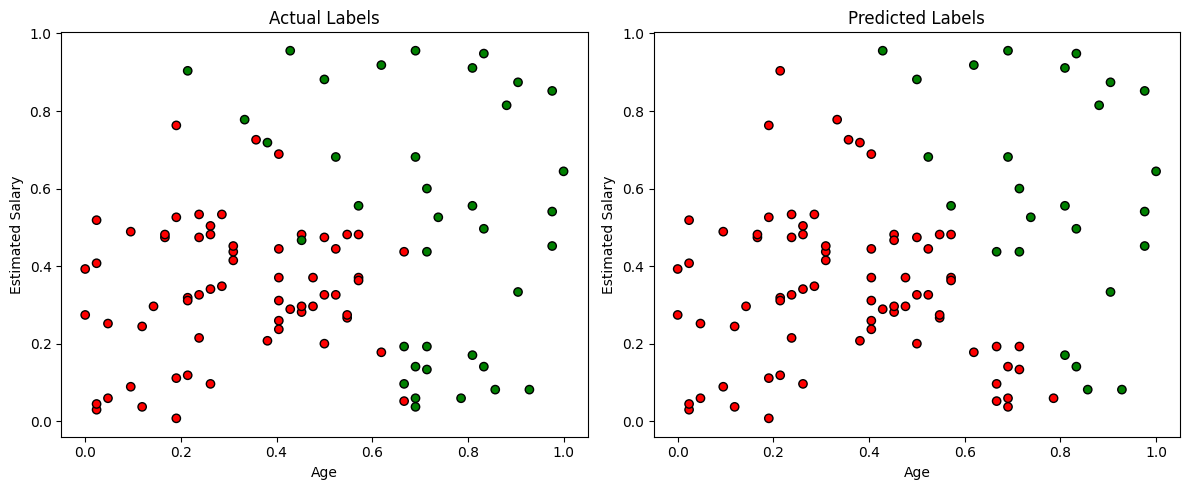

In [50]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Actual labels
axs[0].scatter(X_test['Age'], X_test['EstimatedSalary'], c=y_test, cmap=ListedColormap(['red', 'green']), edgecolor='k')
axs[0].set_title('Actual Labels')
axs[0].set_xlabel('Age')
axs[0].set_ylabel('Estimated Salary')

# Predicted labels
axs[1].scatter(X_test['Age'], X_test['EstimatedSalary'], c=y_pred, cmap=ListedColormap(['red', 'green']), edgecolor='k')
axs[1].set_title('Predicted Labels')
axs[1].set_xlabel('Age')
axs[1].set_ylabel('Estimated Salary')

plt.tight_layout()
plt.show()

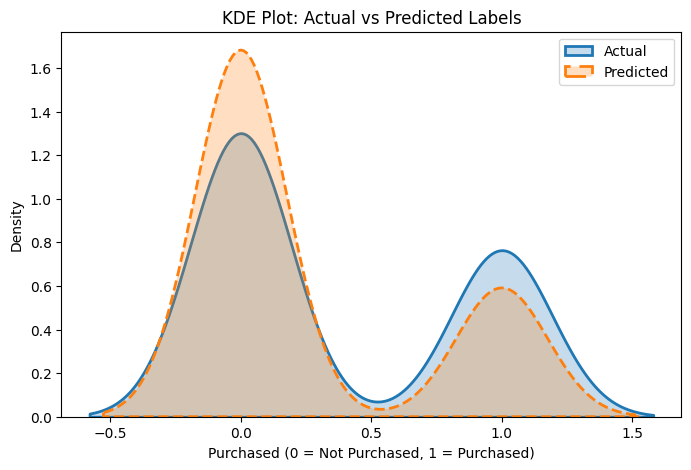

In [52]:
# If 'Purchased' is still a category, convert it to numeric values (0 and 1)
y_test_numeric = y_test.cat.codes
y_pred_numeric = pd.Series(y_pred).astype('category').cat.codes

# Create KDE plot for actual vs predicted
plt.figure(figsize=(8, 5))
sns.kdeplot(y_test_numeric, label='Actual', fill=True, linewidth=2)
sns.kdeplot(y_pred_numeric, label='Predicted', fill=True, linewidth=2, linestyle='--')

plt.title('KDE Plot: Actual vs Predicted Labels')
plt.xlabel('Purchased (0 = Not Purchased, 1 = Purchased)')
plt.legend()
plt.show()
